In [72]:
# !pip install scienceplots
import scienceplots

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("svg")

In [73]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import t as student_t, wilcoxon

STATS_ROOT = Path("stats")

METHOD_ORDER = ["vanilla", "stoch_iso", "operator_norm", "curvature", "stiefel"]

def load_saved_stats(
    selections,
    horizons,
    versions,
    seeds,
    stats_root=STATS_ROOT,
    verbose=True,
):
    out = {"roll": [], "intr": [], "summary": [], "paired": []}
    missing = []

    for selection in selections:
        sel_dir = Path(stats_root) / selection
        for H in horizons:
            for V in versions:
                for seed in seeds:
                    files = {
                        "roll":    sel_dir / f"df_roll_H{H}_v{V}_{seed}.csv",
                        "intr":    sel_dir / f"df_intr_H{H}{V}_{seed}.csv",   # matches your current naming
                        "summary": sel_dir / f"summary_H{H}_v{V}_{seed}.csv",
                        "paired":  sel_dir / f"paired_H{H}_v{V}_{seed}.csv",
                    }

                    for kind, path in files.items():
                        if path.exists():
                            if kind == "summary":
                                df = pd.read_csv(path, header=[0, 1], index_col=0)
                                df.columns = [
                                    f"{a}_{b}" if str(b) != "" else str(a)
                                    for a, b in df.columns.to_flat_index()
                                ]
                                df = df.reset_index().rename(columns={"index": "method"})
                            else:
                                df = pd.read_csv(path)

                            df["selection"] = selection
                            df["horizon"] = H
                            df["V"] = V
                            df["seed"] = seed
                            out[kind].append(df)
                        else:
                            missing.append((kind, str(path)))

    result = {
        kind: (pd.concat(parts, ignore_index=True) if parts else pd.DataFrame())
        for kind, parts in out.items()
    }

    if verbose:
        print("Loaded:")
        for kind, df in result.items():
            print(f"  {kind:>7}: {len(df):>8} rows")
        if missing:
            print(f"\nMissing files: {len(missing)}")
            for kind, path in missing[:20]:
                print(f"  [{kind}] {path}")
            if len(missing) > 20:
                print("  ...")

    return result


SELECTIONS = ["best_swa", "target_swa"]
HORIZONS = [80, 160, 240, 320]
VERSIONS = [1, 2]
SEEDS = list(range(1, 16+1))

stats = load_saved_stats(
    selections=SELECTIONS,
    horizons=HORIZONS,
    versions=VERSIONS,
    seeds=SEEDS,
    stats_root=STATS_ROOT,
    verbose=True,
)

df_roll = stats["roll"]
df_intr = stats["intr"]

Loaded:
     roll:   860000 rows
     intr:   412800 rows
  summary:      860 rows
   paired:      688 rows

Missing files: 336
  [roll] stats/target_swa/df_roll_H80_v1_5.csv
  [intr] stats/target_swa/df_intr_H801_5.csv
  [summary] stats/target_swa/summary_H80_v1_5.csv
  [paired] stats/target_swa/paired_H80_v1_5.csv
  [roll] stats/target_swa/df_roll_H80_v1_6.csv
  [intr] stats/target_swa/df_intr_H801_6.csv
  [summary] stats/target_swa/summary_H80_v1_6.csv
  [paired] stats/target_swa/paired_H80_v1_6.csv
  [roll] stats/target_swa/df_roll_H80_v1_7.csv
  [intr] stats/target_swa/df_intr_H801_7.csv
  [summary] stats/target_swa/summary_H80_v1_7.csv
  [paired] stats/target_swa/paired_H80_v1_7.csv
  [roll] stats/target_swa/df_roll_H80_v1_8.csv
  [intr] stats/target_swa/df_intr_H801_8.csv
  [summary] stats/target_swa/summary_H80_v1_8.csv
  [paired] stats/target_swa/paired_H80_v1_8.csv
  [roll] stats/target_swa/df_roll_H80_v1_9.csv
  [intr] stats/target_swa/df_intr_H801_9.csv
  [summary] stats/ta

In [75]:
# Cell 2: helpers for run-level summaries and confidence intervals

def add_ci_from_std(df, mean_col, std_col, n_col, ci_level=0.95, out_col="ci95"):
    df = df.copy()
    alpha = 1.0 - ci_level

    def _halfwidth(row):
        n = row[n_col]
        s = row[std_col]
        if pd.isna(n) or pd.isna(s) or n < 2:
            return np.nan
        tcrit = student_t.ppf(1 - alpha / 2, df=n - 1)
        return tcrit * s / np.sqrt(n)

    df[out_col] = df.apply(_halfwidth, axis=1)
    return df


def compute_run_level_rollout(df_roll, selection, horizons, versions, seeds, metrics=("rel_mean", "rel_max")):
    """
    Step 1: average over windows within each (selection, horizon, V, seed, method)
    """
    df = df_roll.copy()
    df = df[
        df["selection"].eq(selection)
        & df["horizon"].isin(horizons)
        & df["V"].isin(versions)
        & df["seed"].isin(seeds)
    ].copy()

    if df.empty:
        return pd.DataFrame()

    agg_dict = {m: (m, "mean") for m in metrics}

    run_level = (
        df.groupby(["selection", "horizon", "V", "seed", "method"], as_index=False)
          .agg(**agg_dict)
    )
    return run_level


def summarize_run_level_metric(run_level, metric):
    """
    Step 2: summarize across (V, seed) realizations
    """
    g = (
        run_level.groupby(["selection", "horizon", "method"], as_index=False)
        .agg(
            mean=(metric, "mean"),
            std=(metric, "std"),
            n=(metric, "size"),
        )
    )
    g = add_ci_from_std(g, mean_col="mean", std_col="std", n_col="n", out_col="ci95")
    return g.sort_values(["horizon", "method"]).reset_index(drop=True)


def pretty_round(df, digits=5):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out

In [76]:
# Cell 1: publication-style plotting setup

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ["vanilla", "stoch_iso", "operator_norm", "curvature", "stiefel"]
METHOD_LABELS = {
    "vanilla": "vanilla",
    "stoch_iso": "isometry penalty",
    "operator_norm": "gain penalty",
    "curvature": "curvature penalty",
    "stiefel": "stiefel projection",
}
METHOD_MARKERS = {
    "vanilla": "o",
    "stoch_iso": "s",
    "operator_norm": "^",
    "curvature": "X",
    "stiefel": "D",
}

# Try SciencePlots; fall back to manual rcParams if unavailable
try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
    print("Using SciencePlots style.")
except Exception:
    print("SciencePlots not available; using manual Matplotlib styling.")
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "legend.frameon": False,
        "lines.linewidth": 1.8,
        "lines.markersize": 6,
    })


def save_pub_figure(fig, stem, save_svg=True, save_pdf=True):
    if save_svg:
        svg_path = FIG_DIR / f"{stem}.svg"
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"Saved: {svg_path}")
    if save_pdf:
        pdf_path = FIG_DIR / f"{stem}.pdf"
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
        print(f"Saved: {pdf_path}")

Using SciencePlots style.


In [77]:
# Cell 2: helper to make publication-style line plots with CI bands

def plot_metric_vs_horizon(
    plot_df,
    metric_title,
    y_label,
    horizons,
    filename_stem,
    legend_outside=False,
):
    """
    Expects plot_df with columns:
      selection, horizon, method, mean, std, n, ci95
    """
    fig, ax = plt.subplots(figsize=(6.6, 4.2))

    # Keep a deterministic draw order
    plot_df = plot_df.copy()
    plot_df["method"] = pd.Categorical(plot_df["method"], categories=METHOD_ORDER, ordered=True)
    plot_df = plot_df.sort_values(["method", "horizon"])

    for method in METHOD_ORDER:
        sub = plot_df[plot_df["method"] == method].sort_values("horizon")
        if sub.empty:
            continue

        x = sub["horizon"].to_numpy()
        y = sub["mean"].to_numpy()
        ci = sub["ci95"].to_numpy()

        # CI band
        ax.fill_between(
            x,
            y - ci,
            y + ci,
            alpha=0.15,
            linewidth=0,
            zorder=1,
        )

        # Line + markers
        ax.plot(
            x,
            y,
            marker=METHOD_MARKERS.get(method, "o"),
            label=METHOD_LABELS.get(method, method),
            zorder=3,
        )

    ax.set_xlabel("Rollout horizon")
    ax.set_ylabel(y_label)
    ax.set_title(metric_title)
    ax.set_xticks(horizons)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Light horizontal guide only
    ax.grid(axis="y", alpha=0.20, linewidth=0.8)

    if legend_outside:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    else:
        ax.legend(ncol=2)

    fig.tight_layout()
    save_pub_figure(fig, filename_stem, save_svg=True, save_pdf=True)
    plt.show()

    return fig, ax

In [78]:
# Cell 3: prepare plotting tables (best_swa)

# SELECTION_PLOT = "best_swa"
# HORIZONS_PLOT = [80,160, 240, 320]
# VERSIONS_PLOT = [1, 2]
# SEEDS_PLOT = list(range(1, 17))

SELECTION_PLOT = "target_swa"
HORIZONS_PLOT = [320]
VERSIONS_PLOT = [1]
SEEDS_PLOT = list(range(1, 17))

run_level_plot = compute_run_level_rollout(
    df_roll=df_roll,
    selection=SELECTION_PLOT,
    horizons=HORIZONS_PLOT,
    versions=VERSIONS_PLOT,
    seeds=SEEDS_PLOT,
    metrics=("rel_mean", "rel_max"),
)

plot_rel_mean = summarize_run_level_metric(run_level_plot, "rel_mean")
plot_rel_max  = summarize_run_level_metric(run_level_plot, "rel_max")

display(pretty_round(plot_rel_mean))
display(pretty_round(plot_rel_max))

,selection,horizon,method,mean,std,n,ci95
0,target_swa,320,curvature,0.16926,0.01224,16,0.00652
1,target_swa,320,operator_norm,0.16755,0.00977,16,0.00521
2,target_swa,320,stiefel,0.14598,0.00948,16,0.00505
3,target_swa,320,stoch_iso,0.16573,0.00769,16,0.00410
4,target_swa,320,vanilla,0.15109,0.01075,16,0.00573


,selection,horizon,method,mean,std,n,ci95
0,target_swa,320,curvature,0.24583,0.02028,16,0.01081
1,target_swa,320,operator_norm,0.24353,0.01333,16,0.00711
2,target_swa,320,stiefel,0.22120,0.01346,16,0.00717
3,target_swa,320,stoch_iso,0.24173,0.00913,16,0.00487
4,target_swa,320,vanilla,0.22994,0.01660,16,0.00885


Saved: figures/rollout_rel_mean_best_swa_pub.svg
Saved: figures/rollout_rel_mean_best_swa_pub.pdf


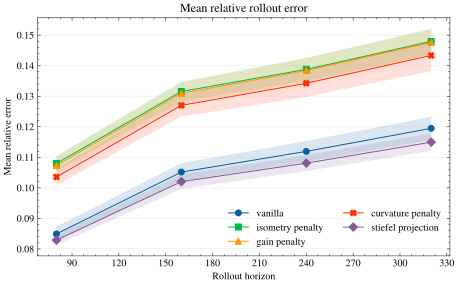

(<Figure size 660x420 with 1 Axes>,
 <Axes: title={'center': 'Mean relative rollout error'}, xlabel='Rollout horizon', ylabel='Mean relative error'>)

In [69]:
# Cell 4: publication-style rel_mean plot

plot_metric_vs_horizon(
    plot_df=plot_rel_mean,
    metric_title="Mean relative rollout error",
    y_label="Mean relative error",
    horizons=HORIZONS_PLOT,
    filename_stem="rollout_rel_mean_best_swa_pub",
    legend_outside=False,   # set True if the legend feels crowded
)

Saved: figures/rollout_rel_max_best_swa_pub.svg
Saved: figures/rollout_rel_max_best_swa_pub.pdf


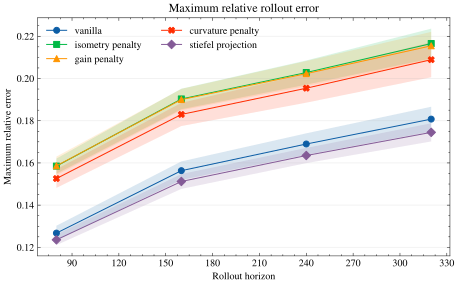

(<Figure size 660x420 with 1 Axes>,
 <Axes: title={'center': 'Maximum relative rollout error'}, xlabel='Rollout horizon', ylabel='Maximum relative error'>)

In [70]:
# Cell 5: publication-style rel_max plot

plot_metric_vs_horizon(
    plot_df=plot_rel_max,
    metric_title="Maximum relative rollout error",
    y_label="Maximum relative error",
    horizons=HORIZONS_PLOT,
    filename_stem="rollout_rel_max_best_swa_pub",
    legend_outside=False,   # set True if the legend feels crowded
)

In [48]:
# Cell 5: paired delta table vs vanilla at H=320 (best_swa)

def make_paired_delta_table(
    df_roll,
    selection,
    horizons,
    versions,
    seeds,
    metrics=("rel_mean", "rel_max"),
    baseline="vanilla",
):
    """
    For each metric:
      1) pair windows exactly using (selection, horizon, V, seed, window_id)
      2) compute delta = baseline - method at window level
      3) average over windows within each (V, seed)
      4) summarize across (V, seed)
    """
    df = df_roll.copy()
    df = df[
        df["selection"].eq(selection)
        & df["horizon"].isin(horizons)
        & df["V"].isin(versions)
        & df["seed"].isin(seeds)
    ].copy()

    pair_keys = ["selection", "horizon", "V", "seed", "window_id"]

    wide = df.pivot_table(
        index=pair_keys,
        columns="method",
        values=list(metrics),
        aggfunc="first",
    )

    methods_present = sorted(set(wide.columns.get_level_values(1)))
    if baseline not in methods_present:
        raise ValueError(f"Missing baseline '{baseline}'. Found methods: {methods_present}")

    methods = [m for m in METHOD_ORDER if m in methods_present and m != baseline]

    rows = []
    for metric in metrics:
        for method in methods:
            if (metric, baseline) not in wide.columns or (metric, method) not in wide.columns:
                continue

            sub = wide[[(metric, baseline), (metric, method)]].dropna()
            if sub.empty:
                continue

            delta = sub[(metric, baseline)] - sub[(metric, method)]  # positive => method better
            tmp = delta.reset_index(name="delta")
            tmp["metric"] = metric
            tmp["method"] = method
            rows.append(tmp)

    df_delta = pd.concat(rows, ignore_index=True)

    # one paired effect per (V, seed)
    pair_level = (
        df_delta.groupby(["selection", "horizon", "V", "seed", "metric", "method"], as_index=False)
        .agg(
            delta_mean=("delta", "mean"),
            n_windows=("delta", "size"),
        )
    )

    summary = (
        pair_level.groupby(["selection", "horizon", "metric", "method"], as_index=False)
        .agg(
            paired_delta_mean=("delta_mean", "mean"),
            paired_delta_std=("delta_mean", "std"),
            paired_delta_median=("delta_mean", "median"),
            n_pairs=("delta_mean", "size"),
        )
    )
    summary = add_ci_from_std(summary, "paired_delta_mean", "paired_delta_std", "n_pairs", out_col="ci95")

    # one-sided / two-sided tests on pair-level deltas
    test_rows = []
    for (selection_, horizon_, metric_, method_), g in pair_level.groupby(
        ["selection", "horizon", "metric", "method"]
    ):
        x = g["delta_mean"].dropna().to_numpy()
        p_greater = wilcoxon(x, alternative="greater").pvalue if len(x) >= 5 else np.nan
        p_two = wilcoxon(x, alternative="two-sided").pvalue if len(x) >= 5 else np.nan
        test_rows.append({
            "selection": selection_,
            "horizon": horizon_,
            "metric": metric_,
            "method": method_,
            "p_wilcoxon_greater": p_greater,
            "p_wilcoxon_two_sided": p_two,
        })

    df_tests = pd.DataFrame(test_rows)

    out = summary.merge(
        df_tests,
        on=["selection", "horizon", "metric", "method"],
        how="left",
    )

    out = out.sort_values(
        ["horizon", "metric", "paired_delta_mean"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return pair_level, out


pair_level_320, table_paired_320 = make_paired_delta_table(
    df_roll=df_roll,
    selection="best_swa",
    horizons=[320],
    versions=[1, 2],
    seeds=list(range(1, 17)),
    # metrics=("rel_mean", "rel_max"),
    metrics=("rel_mean", "rel_max"),
    baseline="vanilla",
)

display(pretty_round(table_paired_320))

,selection,horizon,metric,method,paired_delta_mean,paired_delta_std,paired_delta_median,n_pairs,ci95,p_wilcoxon_greater,p_wilcoxon_two_sided
0,best_swa,320,rel_max,stiefel,0.00627,0.01172,0.00640,32,0.00423,0.00104,0.00207
1,best_swa,320,rel_max,curvature,-0.02815,0.02438,-0.02600,32,0.00879,1.00000,0.00000
2,best_swa,320,rel_max,operator_norm,-0.03473,0.02119,-0.03400,32,0.00764,1.00000,0.00000
3,best_swa,320,rel_max,stoch_iso,-0.03581,0.02203,-0.03660,32,0.00794,1.00000,0.00000
4,best_swa,320,rel_mean,stiefel,0.00452,0.00860,0.00475,32,0.00310,0.00181,0.00362
5,best_swa,320,rel_mean,curvature,-0.02387,0.01427,-0.02431,32,0.00514,1.00000,0.00000
6,best_swa,320,rel_mean,operator_norm,-0.02817,0.01285,-0.02882,32,0.00463,1.00000,0.00000
7,best_swa,320,rel_mean,stoch_iso,-0.02843,0.01258,-0.03011,32,0.00454,1.00000,0.00000


In [80]:
pair_level_320_target, table_paired_320_target = make_paired_delta_table(
    df_roll=df_roll,
    selection="target_swa",
    horizons=[320],
    versions=[1],
    seeds=list(range(1, 17)),
    # metrics=("rel_mean", "rel_max"),
    metrics=("rel_mean", "rel_max"),
    baseline="vanilla",
)

display(pretty_round(table_paired_320_target))

,selection,horizon,metric,method,paired_delta_mean,paired_delta_std,paired_delta_median,n_pairs,ci95,p_wilcoxon_greater,p_wilcoxon_two_sided
0,target_swa,320,rel_max,stiefel,0.00874,0.01940,0.00413,16,0.01034,0.05833,0.11667
1,target_swa,320,rel_max,stoch_iso,-0.01179,0.01954,-0.01410,16,0.01041,0.98752,0.02899
2,target_swa,320,rel_max,operator_norm,-0.01359,0.01801,-0.01315,16,0.00960,0.99742,0.00629
3,target_swa,320,rel_max,curvature,-0.01588,0.02026,-0.01490,16,0.01079,0.99742,0.00629
4,target_swa,320,rel_mean,stiefel,0.00512,0.01179,0.00406,16,0.00628,0.07953,0.15906
5,target_swa,320,rel_mean,stoch_iso,-0.01464,0.01208,-0.01565,16,0.00644,0.99962,0.00101
6,target_swa,320,rel_mean,operator_norm,-0.01645,0.01099,-0.01487,16,0.00586,0.99995,0.00015
7,target_swa,320,rel_mean,curvature,-0.01816,0.01237,-0.01921,16,0.00659,0.99989,0.00031


In [83]:
table_paired_320_target_min = table_paired_320_target[["method", "paired_delta_mean", "paired_delta_std", "ci95", "p_wilcoxon_greater"]]

display(pretty_round(table_paired_320_target_min))

,method,paired_delta_mean,paired_delta_std,ci95,p_wilcoxon_greater
0,stiefel,0.00874,0.01940,0.01034,0.05833
1,stoch_iso,-0.01179,0.01954,0.01041,0.98752
2,operator_norm,-0.01359,0.01801,0.00960,0.99742
3,curvature,-0.01588,0.02026,0.01079,0.99742
4,stiefel,0.00512,0.01179,0.00628,0.07953
5,stoch_iso,-0.01464,0.01208,0.00644,0.99962
6,operator_norm,-0.01645,0.01099,0.00586,0.99995
7,curvature,-0.01816,0.01237,0.00659,0.99989


In [30]:
# Cell 6: AE-seed robustness table (H=320, rel_mean only)

def make_ae_seed_table(df_roll, selection="best_swa", horizon=320, versions=(1, 2), seeds=range(1, 17), metric="rel_mean"):
    df = df_roll.copy()
    df = df[
        df["selection"].eq(selection)
        & df["horizon"].eq(horizon)
        & df["V"].isin(list(versions))
        & df["seed"].isin(list(seeds))
    ].copy()

    # average over windows within each (V, seed, method)
    run_level = (
        df.groupby(["V", "seed", "method"], as_index=False)
          .agg(metric_run=(metric, "mean"))
    )

    # summarize over NODE seeds within each AE seed
    ae_summary = (
        run_level.groupby(["V", "method"], as_index=False)
        .agg(
            mean=( "metric_run", "mean"),
            std=(  "metric_run", "std"),
            n=(    "metric_run", "size"),
        )
    )
    ae_summary = add_ci_from_std(ae_summary, "mean", "std", "n", out_col="ci95")

    # wide tables
    wide_mean = ae_summary.pivot(index="V", columns="method", values="mean")
    wide_ci   = ae_summary.pivot(index="V", columns="method", values="ci95")

    # add overall mean/std across AE seeds (note: only 2 AE seeds)
    overall = (
        ae_summary.groupby("method", as_index=False)
        .agg(
            mean=("mean", "mean"),
            std=("mean", "std"),
        )
    )
    overall_mean = overall.set_index("method")["mean"]
    overall_std  = overall.set_index("method")["std"]

    table = wide_mean.copy()
    table.index = [f"AE{v}" for v in table.index]
    table.loc["mean_over_AE"] = overall_mean
    table.loc["std_over_AE"] = overall_std

    # optional companion CI table by AE seed
    ci_table = wide_ci.copy()
    ci_table.index = [f"AE{v}" for v in ci_table.index]

    # reorder columns
    cols = [m for m in METHOD_ORDER if m in table.columns]
    table = table[cols]
    ci_table = ci_table[cols]

    return table, ci_table, ae_summary


table_ae_rel_mean_320, table_ae_rel_mean_ci_320, ae_summary_rel_mean_320 = make_ae_seed_table(
    df_roll=df_roll,
    selection="best_swa",
    horizon=320,
    versions=(1, 2),
    seeds=range(1, 17),
    metric="rel_mean",
)

print("Mean rel_mean by AE seed (averaged over NODE seeds):")
display(pretty_round(table_ae_rel_mean_320))

print("95% CI within each AE seed (across NODE seeds):")
display(pretty_round(table_ae_rel_mean_ci_320))

Mean rel_mean by AE seed (averaged over NODE seeds):


method,vanilla,stoch_iso,operator_norm,curvature,stiefel
AE1,0.12040,0.14803,0.14878,0.14594,0.11552
AE2,0.11858,0.14781,0.14653,0.14078,0.11443
mean_over_AE,0.11949,0.14792,0.14766,0.14336,0.11498
std_over_AE,0.00129,0.00015,0.00159,0.00365,0.00077


95% CI within each AE seed (across NODE seeds):


method,vanilla,stoch_iso,operator_norm,curvature,stiefel
AE1,0.00625,0.00516,0.00678,0.00612,0.00384
AE2,0.00504,0.00732,0.00562,0.00870,0.00474


In [46]:
# Cell 7: intrinsic metrics table (best_swa, H=320)

def make_intrinsic_table(df_intr, selection="best_swa", horizon=320, versions=(1, 2), seeds=range(1, 17)):
    df = df_intr.copy()
    df = df[
        df["selection"].eq(selection)
        & df["horizon"].eq(horizon)
        & df["V"].isin(list(versions))
        & df["seed"].isin(list(seeds))
    ].copy()

    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    # run-level summaries first
    run_level = (
        df.groupby(["selection", "horizon", "V", "seed", "method"], as_index=False)
          .agg(
              dyn_cond50=("dyn_cond", "median"),
              dyn_cond95=("dyn_cond", lambda s: s.quantile(0.95)),
              dec_gain=("dec_gain", "mean"),
              latent_err=("latent_err", "mean"),
          )
    )

    # summarize across (V, seed)
    summary = (
        run_level.groupby(["selection", "horizon", "method"], as_index=False)
        .agg(
            dyn_cond50_mean=("dyn_cond50", "mean"),
            dyn_cond50_std=("dyn_cond50", "std"),
            dyn_cond95_mean=("dyn_cond95", "mean"),
            dyn_cond95_std=("dyn_cond95", "std"),
            dec_gain_mean=("dec_gain", "mean"),
            dec_gain_std=("dec_gain", "std"),
            latent_err_mean=("latent_err", "mean"),
            latent_err_std=("latent_err", "std"),
            n=("method", "size"),
        )
    )

    # add CI columns for each metric
    for base in ["dyn_cond50", "dyn_cond95", "dec_gain", "latent_err"]:
        summary = add_ci_from_std(
            summary,
            mean_col=f"{base}_mean",
            std_col=f"{base}_std",
            n_col="n",
            out_col=f"{base}_ci95",
        )

    # compact display table
    compact = summary[[
        # "selection", "horizon", 
        "method", 
        # "n",
        "dyn_cond50_mean", 
        "dyn_cond50_ci95",
        # "dyn_cond95_mean", 
        # "dyn_cond95_ci95",
        "dec_gain_mean", 
        "dec_gain_ci95",
        "latent_err_mean",
        "latent_err_ci95",
    ]].sort_values("method")

    compact["method"] = pd.Categorical(compact["method"], categories=METHOD_ORDER, ordered=True)
    compact = compact.sort_values("dyn_cond50_mean").reset_index(drop=True)

    return run_level, compact


intr_run_level_320, table_intr_320 = make_intrinsic_table(
    df_intr=df_intr,
    selection="best_swa",
    horizon=320,
    versions=(1, 2),
    seeds=range(1, 17),
)

display(pretty_round(table_intr_320))

,method,dyn_cond50_mean,dyn_cond50_ci95,dec_gain_mean,dec_gain_ci95,latent_err_mean,latent_err_ci95
0,stiefel,124.21437,11.51467,4.42832,0.09652,0.98784,0.02180
1,vanilla,145.27599,13.98988,3.37966,0.00278,1.15555,0.04337
2,curvature,316.61704,18.96775,1.56998,0.01627,3.43445,0.11861
3,stoch_iso,407.24384,19.86909,1.00009,0.00007,4.06578,0.12158
4,operator_norm,424.32196,21.59590,1.01730,0.00727,4.21714,0.13306


In [ ]:
# Cell 8: appendix-style table for target_swa, H=320

run_level_target = compute_run_level_rollout(
    df_roll=df_roll,
    selection="target_swa",
    horizons=[320],
    versions=[1, 2],
    seeds=list(range(1, 17)),
    metrics=("rel_mean", "rel_max"),
)

target_rel_mean = summarize_run_level_metric(run_level_target, "rel_mean")
target_rel_max  = summarize_run_level_metric(run_level_target, "rel_max")

print("target_swa, H=320, rel_mean:")
display(pretty_round(target_rel_mean))

print("target_swa, H=320, rel_max:")
display(pretty_round(target_rel_max))

In [94]:
# Cell 9: export selected tables to LaTeX

def to_latex_table(df, path=None, index=False, float_fmt="%.3f"):
    latex = df.to_latex(index=index, float_format=lambda x: float_fmt % x)
    if path is not None:
        Path(path).write_text(latex)
    return latex


print(to_latex_table(pretty_round(table_paired_320_target_min), path="table_paired_320_target_min.tex"))

    

\begin{tabular}{lrrrr}
\toprule
method & paired_delta_mean & paired_delta_std & ci95 & p_wilcoxon_greater \\
\midrule
stiefel & 0.009 & 0.019 & 0.010 & 0.058 \\
stoch_iso & -0.012 & 0.020 & 0.010 & 0.988 \\
operator_norm & -0.014 & 0.018 & 0.010 & 0.997 \\
curvature & -0.016 & 0.020 & 0.011 & 0.997 \\
stiefel & 0.005 & 0.012 & 0.006 & 0.080 \\
stoch_iso & -0.015 & 0.012 & 0.006 & 1.000 \\
operator_norm & -0.016 & 0.011 & 0.006 & 1.000 \\
curvature & -0.018 & 0.012 & 0.007 & 1.000 \\
\bottomrule
\end{tabular}



In [104]:
# Cell 1: load training metadata summaries

from pathlib import Path
import pandas as pd
import numpy as np

METHOD_ORDER = ["vanilla", "stoch_iso", "operator_norm", "curvature", "stiefel"]


df_meta = pd.read_csv("stats/metadata.csv")
df_meta

,Unnamed: 0,version,method,run,n_epochs,best_train,best_val,best_train_ep,best_val_ep,target_val,target_ep,target_reached,std_train,std_val,target_swa_epochs,best_swa_epochs,last_swa_epochs
0,0,1,curvature,1,50,0.000795,0.001303,50,38,0.002715,13,True,0.024328,0.019597,"[11, 12, 13]","[36, 37, 38]","[48, 49, 50]"
1,1,1,curvature,2,50,0.000870,0.001077,49,50,0.002715,13,True,0.024476,0.016335,"[11, 12, 13]","[48, 49, 50]","[48, 49, 50]"
2,2,1,curvature,3,50,0.000893,0.001193,49,50,0.002715,20,True,0.023916,0.019758,"[18, 19, 20]","[48, 49, 50]","[48, 49, 50]"
3,3,1,curvature,4,50,0.000859,0.000802,50,45,0.002715,14,True,0.024411,0.018703,"[12, 13, 14]","[43, 44, 45]","[48, 49, 50]"
4,4,1,curvature,5,50,0.000649,0.001932,49,27,0.002715,14,True,0.025473,0.017833,"[12, 13, 14]","[25, 26, 27]","[48, 49, 50]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,155,2,vanilla,12,50,0.000475,0.000768,50,35,0.002715,14,True,0.022452,0.012347,"[12, 13, 14]","[33, 34, 35]","[48, 49, 50]"
156,156,2,vanilla,13,50,0.000596,0.001081,50,23,0.002715,13,True,0.021655,0.010379,"[11, 12, 13]","[21, 22, 23]","[48, 49, 50]"
157,157,2,vanilla,14,50,0.000536,0.000576,49,45,0.002715,11,True,0.021361,0.010238,"[9, 10, 11]","[43, 44, 45]","[48, 49, 50]"
158,158,2,vanilla,15,50,0.000514,0.000502,50,50,0.002715,16,True,0.021447,0.011788,"[14, 15, 16]","[48, 49, 50]","[48, 49, 50]"


In [105]:
# Cell 1: clean metadata df

# Assume your dataframe is already loaded as df_meta
# Example: df_meta = pd.read_csv(...)

df_meta_clean = df_meta.copy()

# Drop CSV index column if present
if "Unnamed: 0" in df_meta_clean.columns:
    df_meta_clean = df_meta_clean.drop(columns=["Unnamed: 0"])

# Basic type cleanup
for col in ["version", "run", "n_epochs", "best_val_ep", "best_train_ep", "target_ep"]:
    if col in df_meta_clean.columns:
        df_meta_clean[col] = pd.to_numeric(df_meta_clean[col], errors="coerce")

for col in ["best_val", "best_train", "std_val", "std_train", "target_val"]:
    if col in df_meta_clean.columns:
        df_meta_clean[col] = pd.to_numeric(df_meta_clean[col], errors="coerce")

display(df_meta_clean.head())
print(df_meta_clean.dtypes)

,version,method,run,n_epochs,best_train,best_val,best_train_ep,best_val_ep,target_val,target_ep,target_reached,std_train,std_val,target_swa_epochs,best_swa_epochs,last_swa_epochs
0,1,curvature,1,50,0.000795,0.001303,50,38,0.002715,13,True,0.024328,0.019597,"[11, 12, 13]","[36, 37, 38]","[48, 49, 50]"
1,1,curvature,2,50,0.000870,0.001077,49,50,0.002715,13,True,0.024476,0.016335,"[11, 12, 13]","[48, 49, 50]","[48, 49, 50]"
2,1,curvature,3,50,0.000893,0.001193,49,50,0.002715,20,True,0.023916,0.019758,"[18, 19, 20]","[48, 49, 50]","[48, 49, 50]"
3,1,curvature,4,50,0.000859,0.000802,50,45,0.002715,14,True,0.024411,0.018703,"[12, 13, 14]","[43, 44, 45]","[48, 49, 50]"
4,1,curvature,5,50,0.000649,0.001932,49,27,0.002715,14,True,0.025473,0.017833,"[12, 13, 14]","[25, 26, 27]","[48, 49, 50]"


version                int64
method                   str
run                    int64
n_epochs               int64
best_train           float64
best_val             float64
best_train_ep          int64
best_val_ep            int64
target_val           float64
target_ep              int64
target_reached          bool
std_train            float64
std_val              float64
target_swa_epochs        str
best_swa_epochs          str
last_swa_epochs          str
dtype: object


In [116]:
# Cell 2: summary table by method

METHOD_ORDER = ["vanilla", "stoch_iso", "operator_norm", "curvature", "stiefel"]

from scipy.stats import t as student_t
import numpy as np
import pandas as pd

def make_training_metadata_summary(df_meta_clean, versions=None, ci_level=0.95):
    df = df_meta_clean.copy()

    # Optional filter by AE version(s)
    if versions is not None:
        versions = versions if isinstance(versions, (list, tuple, set)) else [versions]
        df = df[df["version"].isin(versions)].copy()

    # If target_ep should only be counted when target was actually reached, uncomment:
    # if "target_reached" in df.columns:
    #     df.loc[~df["target_reached"], "target_ep"] = np.nan

    table = (
        df.groupby("method", as_index=False)
          .agg(
              best_val_loss=("best_val", "mean"),
              best_val_loss_std=("best_val", "std"),
              best_val_loss_n=("best_val", "count"),
              target_ep=("target_ep", "mean"),
              target_ep_std=("target_ep", "std"),
              target_ep_n=("target_ep", "count"),
          )
    )

    alpha = 1.0 - ci_level

    def ci_half_width(std_col, n_col):
        out = []
        for s, n in zip(table[std_col], table[n_col]):
            if pd.isna(s) or pd.isna(n) or n < 2:
                out.append(np.nan)
            else:
                tcrit = student_t.ppf(1 - alpha / 2, df=n - 1)
                out.append(tcrit * s / np.sqrt(n))
        return out

    table["best_val_loss_ci95"] = ci_half_width("best_val_loss_std", "best_val_loss_n")
    table["target_ep_ci95"] = ci_half_width("target_ep_std", "target_ep_n")

    # Keep CI columns instead of raw std columns
    table = table[[
        "method",
        "best_val_loss",
        "best_val_loss_ci95",
        "target_ep",
        "target_ep_ci95",
    ]]

    table["method"] = pd.Categorical(table["method"], categories=METHOD_ORDER, ordered=True)
    table = table.sort_values("best_val_loss").reset_index(drop=True)

    return table

table_meta_summary = make_training_metadata_summary(df_meta_clean)
display(table_meta_summary.round(5))

,method,best_val_loss,best_val_loss_ci95,target_ep,target_ep_ci95
0,stiefel,0.00086,0.00010,13.50000,1.54600
1,vanilla,0.00088,0.00012,14.09375,1.42566
2,curvature,0.00114,0.00014,14.46875,1.17983
3,operator_norm,0.00135,0.00018,18.09375,2.45958
4,stoch_iso,0.00144,0.00018,19.25000,3.41792


In [117]:
print(to_latex_table(pretty_round(table_meta_summary), path="table_meta_summary.tex", float_fmt="%.3e"))


\begin{tabular}{lrrrr}
\toprule
method & best_val_loss & best_val_loss_ci95 & target_ep & target_ep_ci95 \\
\midrule
stiefel & 8.600e-04 & 1.000e-04 & 1.350e+01 & 1.546e+00 \\
vanilla & 8.800e-04 & 1.200e-04 & 1.409e+01 & 1.426e+00 \\
curvature & 1.140e-03 & 1.400e-04 & 1.447e+01 & 1.180e+00 \\
operator_norm & 1.350e-03 & 1.800e-04 & 1.809e+01 & 2.460e+00 \\
stoch_iso & 1.440e-03 & 1.800e-04 & 1.925e+01 & 3.418e+00 \\
\bottomrule
\end{tabular}

